In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('spam.csv')
df.head()

,v1,v2,col1,col2,col3
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.isnull().sum()

v1         0
v2         0
col1    5522
col2    5560
col3    5566
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(403)

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.shape

(5169, 5)

In [7]:
df = df.drop(columns=['col1', 'col2', 'col3'])

In [8]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df = df.rename(columns={'v1': 'target', 'v2': 'text'})

In [10]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
df['characters'] = df['text'].apply(lambda x: len(x))

In [12]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [13]:
df['words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['sentence'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))


In [14]:
df.head()

,target,text,characters,words,sentence
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [15]:
df = df.drop(columns=['text'])

In [16]:
df.head()

,target,characters,words,sentence
0,ham,111,24,2
1,ham,29,8,2
2,spam,155,37,2
3,ham,49,13,1
4,ham,61,15,1


In [17]:
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()

In [18]:
df['target'] = lb.fit_transform(df['target'])

In [19]:
df.head()

,target,characters,words,sentence
0,0,111,24,2
1,0,29,8,2
2,1,155,37,2
3,0,49,13,1
4,0,61,15,1


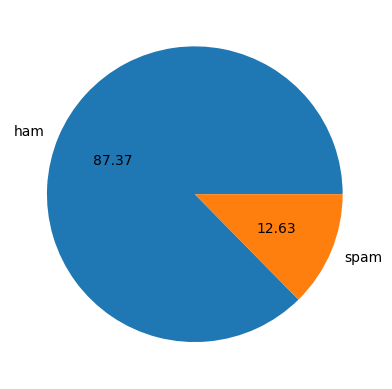

In [20]:
counts = df['target'].value_counts()
plt.pie(counts, labels=['ham', 'spam'], autopct='%0.2f')
plt.show()

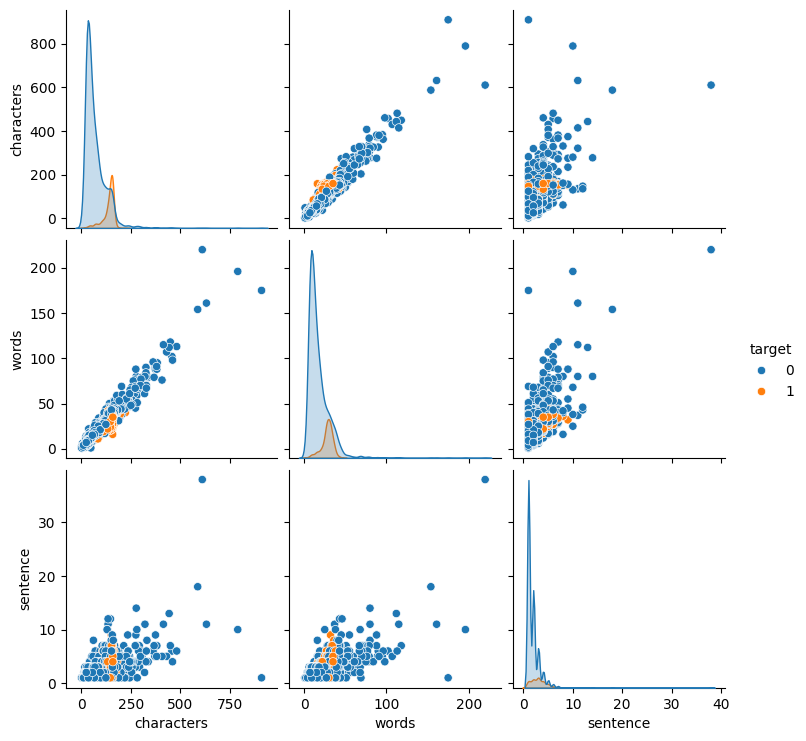

In [21]:
import seaborn as sns
sns.pairplot(df, hue='target')

In [22]:
df[['characters', 'words', 'sentence']].describe()

,characters,words,sentence
count,5169.000000,5169.000000,5169.000000
mean,78.924163,18.456761,1.966531
std,58.175349,13.325633,1.449833
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [23]:
#ham
df[df['target'] == 0][['characters', 'words', 'sentence']].describe()

,characters,words,sentence
count,4516.000000,4516.000000,4516.000000
mean,70.457263,17.123782,1.820195
std,56.357463,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [24]:
#spam
df[df['target'] == 1][['characters', 'words', 'sentence']].describe()

,characters,words,sentence
count,653.000000,653.000000,653.000000
mean,137.479326,27.675345,2.978560
std,30.014336,7.011513,1.493185
min,13.000000,2.000000,1.000000
25%,131.000000,25.000000,2.000000
50%,148.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,223.000000,46.000000,9.000000


<Axes: xlabel='characters', ylabel='Count'>

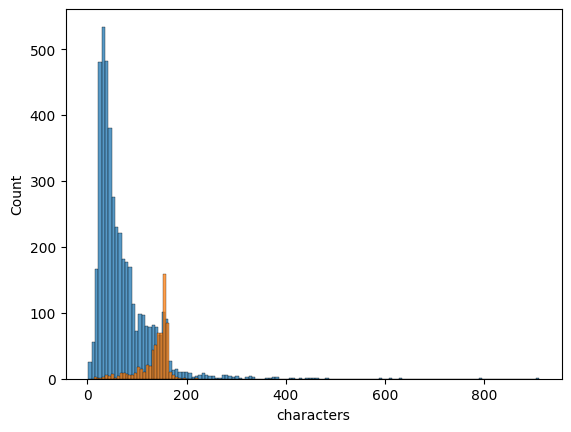

In [25]:
sns.histplot(df[df['target'] == 0]['characters'])
sns.histplot(df[df['target'] == 1]['characters'])

<Axes: xlabel='words', ylabel='Count'>

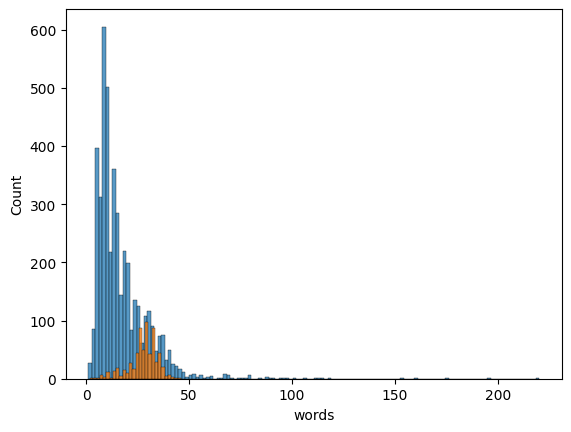

In [26]:
sns.histplot(df[df['target'] == 0]['words'])
sns.histplot(df[df['target'] == 1]['words'])

<Axes: xlabel='sentence', ylabel='Count'>

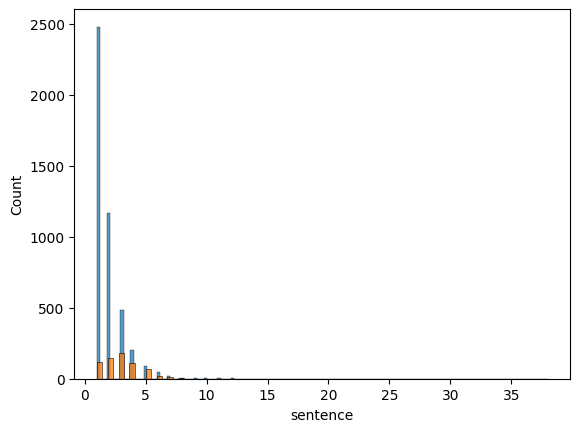

In [27]:
sns.histplot(df[df['target'] == 0]['sentence'])
sns.histplot(df[df['target'] == 1]['sentence'])

In [28]:
# sns.heatmap(df.corr(), annot = True, cmap='coolwarm')

In [29]:
df['text'] = pd.read_csv('spam.csv', usecols=['v2']).drop_duplicates(keep='first')
df.head()

,target,characters,words,sentence,text
0,0,111,24,2,"Go until jurong point, crazy.. Available only ..."
1,0,29,8,2,Ok lar... Joking wif u oni...
2,1,155,37,2,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,49,13,1,U dun say so early hor... U c already then say...
4,0,61,15,1,"Nah I don't think he goes to usf, he lives aro..."


In [30]:
import string
# string.punctuation
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
# stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [31]:
from nltk.stem.porter import PorterStemmer
prt = PorterStemmer()

In [32]:
def transform_text(text):
    #lower
    text = text.lower()
    res = []
    text = nltk.word_tokenize(text);
    for i in text:
        #special character 
        if i.isalnum():
            #stopwords and punctuation
            if i not in stopwords.words('english') and i not in string.punctuation:
                #stemming
                res.append(prt.stem(i))
    # print(text)

    return (" ").join(res)

In [33]:
df['transformed_text'] = df['text'].apply(transform_text)

In [34]:
from wordcloud import WordCloud
wc = WordCloud(height=500, width=500, background_color='white', min_font_size=10)

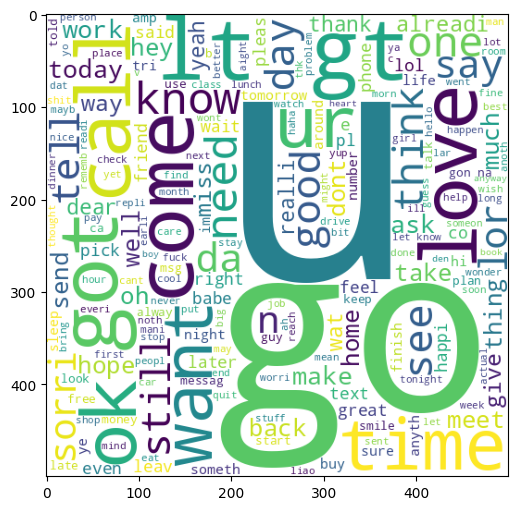

In [35]:
spam_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize=(12,6))
plt.imshow(spam_wc)
plt.show()

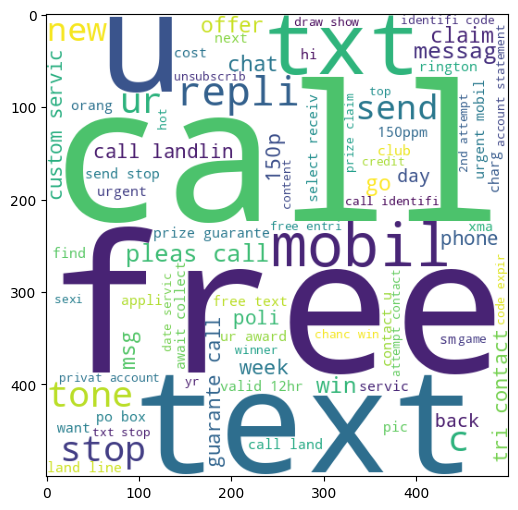

In [36]:
ham_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize=(12,6))
plt.imshow(ham_wc)
plt.show()

In [37]:
spam_corpus = []
for text in df[df['target'] == 1]['transformed_text'].tolist():
    for msg in text.split():
        spam_corpus.append(msg)

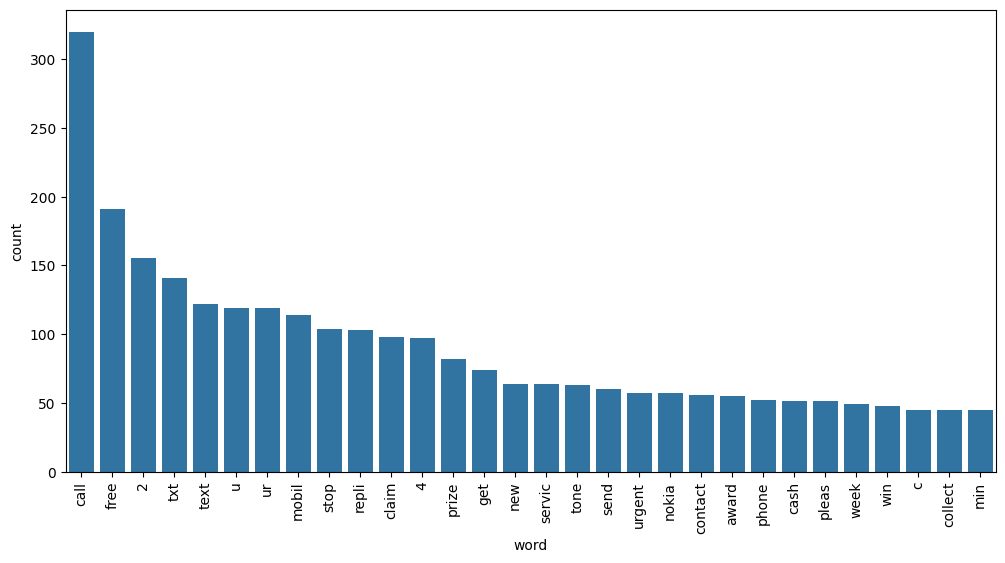

In [38]:
from collections import Counter
import seaborn as sns
# sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30))[0], pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
# type(Counter(spam_corpus).most_common(30))
# spam_corpus

top_words = pd.DataFrame(
    Counter(spam_corpus).most_common(30),
    columns=['word', 'count']
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_words, x='word', y='count')
plt.xticks(rotation=90)
plt.show()

In [39]:
ham_corpus = []
for sent in df[df['target'] == 0]['transformed_text'].tolist():
    for word in sent.split():
        ham_corpus.append(word)

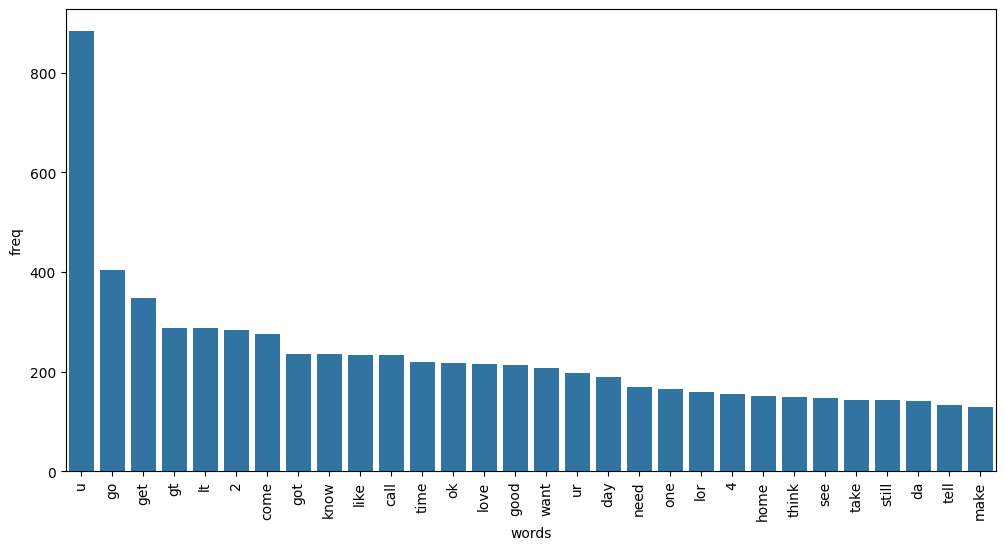

In [40]:
top_words = pd.DataFrame(
    Counter(ham_corpus).most_common(30),
    columns=['words', 'freq']
)
plt.figure(figsize=(12,6))
sns.barplot(top_words, x='words', y='freq')
plt.xticks(rotation=90)
plt.show()

# model building

In [59]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
# tfidf = TfidfVectorizer(max_features=3000)
x = cv.fit_transform(df['transformed_text']).toarray()
# x = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target']

In [42]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
x_scaled = mms.fit_transform(x)

In [43]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size = 0.2, random_state = 42)

In [44]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [45]:
gb = GaussianNB()
gb.fit(x_train, y_train)
gPred = gb.predict(x_test)
print('Accuracy score: ', accuracy_score(gPred, y_test))
print('Precision score: ', precision_score(gPred, y_test))
print('Confusion Matrix:\n', confusion_matrix(gPred, y_test)) 

Accuracy score:  0.8665377176015474
Precision score:  0.8689655172413793
Confusion Matrix:
 [[770  19]
 [119 126]]


In [46]:
mb = MultinomialNB()
mb.fit(x_train, y_train)
mPred = mb.predict(x_test)
print('Accuracy score: ', accuracy_score(mPred, y_test))
print('Precision score: ', precision_score(mPred, y_test))
print('Confusion Matrix:\n', confusion_matrix(mPred, y_test)) 

Accuracy score:  0.9787234042553191
Precision score:  0.9241379310344827
Confusion Matrix:
 [[878  11]
 [ 11 134]]


In [47]:
bb = BernoulliNB()
bb.fit(x_train, y_train)
bPred = bb.predict(x_test)
print('Accuracy score: ', accuracy_score(bPred, y_test))
print('Precision score: ', precision_score(bPred, y_test))
print('Confusion Matrix:\n', confusion_matrix(bPred, y_test)) 

Accuracy score:  0.9661508704061895
Precision score:  0.7862068965517242
Confusion Matrix:
 [[885  31]
 [  4 114]]


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from xgboost import XGBClassifier

In [49]:
models = {
    "Logistic Regression": LogisticRegression(solver='liblinear'),
    "Support Vector Machine": SVC(kernel = 'sigmoid', gamma = 0.1),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators = 50, random_state = 2),
    "Extra Trees": ExtraTreesClassifier(n_estimators = 50, random_state = 2),
    "AdaBoost": AdaBoostClassifier(n_estimators = 50, random_state = 2),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators = 50, random_state = 2),
    "Bagging": BaggingClassifier(n_estimators = 50, random_state = 2),
    "XGBoost": XGBClassifier(n_estimators = 50, random_state = 2)
}

In [50]:
def generate_metrics(model, x_train, y_train, y_test, x_test):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    return accuracy_score(y_pred, y_test), precision_score(y_pred, y_test)

In [ ]:
accuracy = []
precision = []
for name, model in models.items():
    acc, prec = generate_metrics(model, x_train, y_train, y_test, x_test)
    accuracy.append(acc)
    precision.append(prec)
    print(name, acc, prec)

In [ ]:
temp_scale = pd.DataFrame({'Algo': models.keys(), 'Accuracy_scale': accuracy, 'Precision_scale': precision}).sort_values('Precision_scale', ascending=False)
performance_df = performance_df.merge(temp_scale, on='Algo')
performance_df

,Algo,Accuracy,Precision,Accuracy_tfidf,Precision_tfidf,Accuracy_tfidf_3000,Precision_tfidf_3000,Accuracy_scale,Precision_scale
0,Multinomial Naive Bayes,0.972921,0.924138,0.961315,0.731034,0.972921,0.813793,0.978723,0.924138
1,Logistic Regression,0.978723,0.868966,0.949710,0.682759,0.958414,0.744828,0.970986,0.806897
2,Support Vector Machine,0.977756,0.868966,0.911025,0.372414,0.930368,0.517241,0.974855,0.827586
3,Extra Trees,0.977756,0.841379,0.976789,0.841379,0.971954,0.827586,0.977756,0.841379
4,XGBoost,0.970019,0.834483,0.972921,0.841379,0.967118,0.800000,0.970019,0.834483
5,Bagging,0.955513,0.779310,0.962282,0.841379,0.961315,0.848276,0.955513,0.779310
6,Random Forest,0.965184,0.758621,0.970019,0.793103,0.972921,0.813793,0.965184,0.758621
7,Gradient Boosting,0.934236,0.613793,0.952611,0.689655,0.951644,0.689655,0.934236,0.613793
8,Decision Tree,0.922631,0.489655,0.934236,0.703448,0.931335,0.668966,0.924565,0.496552
9,AdaBoost,0.907157,0.400000,0.914894,0.537931,0.914894,0.531034,0.907157,0.400000


In [ ]:
performance_df_melt = pd.melt(performance_df, id_vars=['Algo'], var_name='Metric', value_name='Score')

In [ ]:
pr

In [ ]:
performance_df_melt

,Algo,Metric,Score
0,Multinomial Naive Bayes,Accuracy,0.972921
1,Logistic Regression,Accuracy,0.978723
2,Support Vector Machine,Accuracy,0.977756
3,Extra Trees,Accuracy,0.977756
4,XGBoost,Accuracy,0.970019
5,Bagging,Accuracy,0.955513
6,Random Forest,Accuracy,0.965184
7,Gradient Boosting,Accuracy,0.934236
8,Decision Tree,Accuracy,0.922631
9,AdaBoost,Accuracy,0.907157


In [ ]:
import seaborn as sns

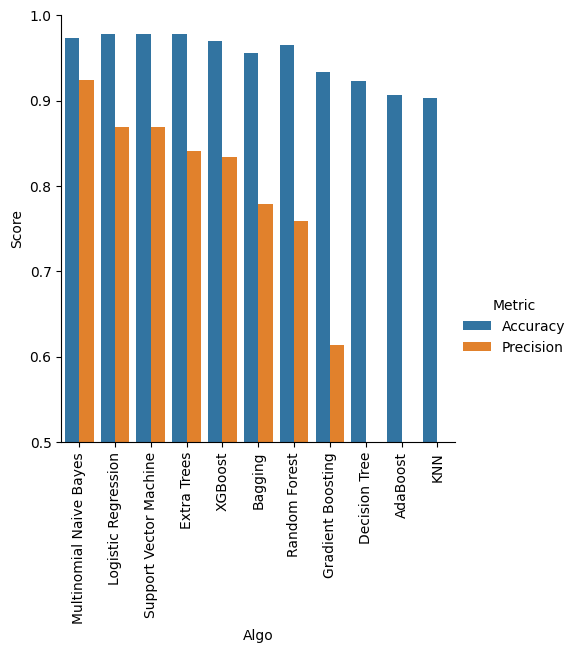

In [ ]:
sns.catplot(x='Algo', y='Score', hue='Metric', data=performance_df_melt, kind='bar', height=5)
plt.ylim(0.5, 1)
plt.xticks(rotation='vertical')
plt.show()

In [60]:
import pickle
pickle.dump(cv, open('count_vectorizer.pkl', 'wb'))
pickle.dump(mb, open('model.pkl', 'wb'))